In [3]:
import os
import shutil
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import seaborn as sns
import torch as torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, random_split
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import pickle

In [4]:
transform = transforms.Compose([
    transforms.Grayscale(),  # Convert images to grayscale if not already
    transforms.RandomResizedCrop(size =256, scale= (0.8, 1.0) ),
    #transforms.Resize((224, 224)),  # Resize images to a fixed size
    transforms.RandomRotation(degrees=15),
    transforms.RandomHorizontalFlip(),
    transforms.CenterCrop(size =224),
    transforms.ToTensor(),  # Convert images to PyTorch tensors
    transforms.Normalize(mean=[0.5], std=[0.5])  # Normalize the images
])
# Loading each dataset
train_data = datasets.ImageFolder(root='/Users/manish/Desktop/final_project/chest_xray/chest_xray_dataset/train', transform=transform)
valid_data = datasets.ImageFolder(root='/Users/manish/Desktop/final_project/chest_xray/chest_xray_dataset/val', transform=transform)
test_data = datasets.ImageFolder(root='/Users/manish/Desktop/final_project/chest_xray/chest_xray_dataset/test', transform=transform)

# Combining datasets
total_dataset = torch.utils.data.ConcatDataset([train_data, valid_data, test_data])

# Define the split sizes
train_size = int(0.7 * len(total_dataset))
valid_size = int(0.15 * len(total_dataset))
test_size = len(total_dataset) - train_size - valid_size

# Randomly split the dataset into train, valid, test
train_dataset, valid_dataset, test_dataset = random_split(total_dataset, [train_size, valid_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [5]:
import torchvision.models as models
googlenet = models.googlenet(pretrained=True)
googlenet.conv1.conv = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)

num_classes = 2
googlenet.fc = nn.Linear(googlenet.fc.in_features, num_classes)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=GoogLeNet_Weights.IMAGENET1K_V1`. You can also use `weights=GoogLeNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /Users/manish/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1000)>

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
googlenet.to(device)

NameError: name 'googlenet' is not defined

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(googlenet.parameters(), lr=0.001)

def train_val_model(model, train_loader, validation_loader, criterion, optimizer, epochs):
    best_val_loss = float('inf')
    best_model_state = None
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        correct_train = 0.0
        total_train = 0.0
        
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)  # Move inputs and targets to the GPU
            targets = targets.squeeze().long()
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_train += targets.size(0)
            correct_train += (predicted == targets).sum().item()

        avg_train_loss = train_loss / len(train_loader.dataset)
        train_accuracy = 100 * correct_train / total_train
        train_losses.append(avg_train_loss)
        train_accuracies.append(train_accuracy)
        print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_train_loss:.4f}, Training Accuracy: {train_accuracy:.2f}%')

        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for inputs, targets in validation_loader:
                inputs, targets = inputs.to(device), targets.to(device)  # Move inputs and targets to the GPU
                targets = targets.squeeze().long()
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                total_val += targets.size(0)
                correct_val += (predicted == targets).sum().item()

        avg_val_loss = val_loss / len(validation_loader.dataset)
        validation_accuracy = 100 * correct_val / total_val
        val_losses.append(avg_val_loss)
        val_accuracies.append(validation_accuracy)
        print(f'Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {validation_accuracy:.2f}%')

    return train_losses, val_losses, train_accuracies, val_accuracies

epochs = 10
train_losses, val_losses, train_accuracies, val_accuracies = train_val_model(googlenet, train_loader, valid_loader, criterion, optimizer, epochs=epochs)

In [ ]:
import torch
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt

# Ensure device is set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Set the model in evaluation mode
model.eval()
test_loss = 0.0
correct_test = 0
total_test = 0
predictions = []
true_labels = []
predicted_probs = []
test_accuracies_early = []
test_losses = []
best_test_accuracy = 0.0

# No gradient calculation needed during testing
with torch.no_grad():
    for data in test_loader:
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)  # Move inputs and labels to GPU
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        
        _, predicted = torch.max(outputs, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()
        
        predictions.extend(predicted.cpu().numpy())  # Move predictions back to CPU for further processing
        true_labels.extend(labels.cpu().numpy())  # Move true labels back to CPU for further processing
        predicted_probs.extend(torch.softmax(outputs, dim=1).cpu().numpy())  # Store softmax probabilities

# Calculate test accuracy and loss
test_accuracy = 100 * correct_test / total_test
test_loss = test_loss / len(test_loader)

# Storing the test loss values for each batch into a list
test_losses.append(test_loss)
# Similarly storing accuracies into a list
test_accuracies_early.append(test_accuracy)

print(f'Test Accuracy: {test_accuracy:.2f}%')

if test_accuracy > best_test_accuracy:
    best_test_accuracy = test_accuracy

# Calculating the precision, recall, and F1 score
precision = precision_score(true_labels, predictions, average='weighted')
recall = recall_score(true_labels, predictions, average='weighted')
f1 = f1_score(true_labels, predictions, average='weighted')

print(f'Test Accuracy: {best_test_accuracy:.2f}%')
print(f'Final Precision: {precision:.4f}')
print(f'Final Recall: {recall:.4f}')
print(f'Final F1 Score: {f1:.4f}')

## Improved Googlenet Model

In [ ]:
# Load the pretrained GoogLeNet model
googlenet_imp = models.googlenet(pretrained=True)

# Modify the first convolution layer for 1 channel input
googlenet_imp.conv1.conv = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)

# Assuming binary classification (e.g., normal vs. pneumonia)
num_classes = 2

# Adding dropout before the final fully connected layer
num_features = googlenet_imp.fc.in_features  # Get the number of inputs into the final layer
googlenet_imp.fc = nn.Sequential(
    nn.Dropout(0.5),  # Adding 50% dropout
    nn.Linear(num_features, num_classes)  # Final fully connected layer
)

# Check if CUDA is available and move the model to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
googlenet_imp.to(device)

# Example of defining a loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(googlenet_imp.parameters(), lr=0.001, weight_decay=0.0005)

In [ ]:
def train_val_model(model, train_loader, validation_loader, criterion, optimizer, epochs, patience):
    best_val_loss = float('inf')
    best_model_state = None
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    no_improvement_count = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        correct_train = 0.0
        total_train = 0.0
        
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)  # Move inputs and targets to the GPU
            targets = targets.squeeze().long()
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_train += targets.size(0)
            correct_train += (predicted == targets).sum().item()

        avg_train_loss = train_loss / len(train_loader.dataset)
        train_accuracy = 100 * correct_train / total_train
        train_losses.append(avg_train_loss)
        train_accuracies.append(train_accuracy)

        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for inputs, targets in validation_loader:
                inputs, targets = inputs.to(device), targets.to(device)  # Move inputs and targets to the GPU
                targets = targets.squeeze().long()
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                total_val += targets.size(0)
                correct_val += (predicted == targets).sum().item()
                
        # Calculate validation accuracy and loss
        avg_val_loss = val_loss / len(validation_loader.dataset)
        val_accuracy = 100 * correct_val / total_val

        val_losses.append(avg_val_loss)
        val_accuracies.append(val_accuracy)
        
        print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_train_loss:.4f}, Training Accuracy: {train_accuracy:.2f}%')
        print(f'Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%')
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict()
            no_improvement_count = 0
        else:
            no_improvement_count += 1

        if no_improvement_count >= patience:
            print(f'Early stopping at epoch {epoch+1} out of {epochs}')
            break
    
    # Save the best model
    if best_model_state is not None:
        torch.save(best_model_state, 'manishbi_hsriram_swanitha_project_checkpoint2_resnet.pkl')
        print(f'Saved best model with validation loss: {best_val_loss:.4f}')

    return train_losses, val_losses, train_accuracies, val_accuracies

epochs = 15
patience = 2  # Number of epochs with no improvement after which training will be stopped
train_losses, val_losses, train_accuracies, val_accuracies = train_val_model(googlenet_imp, train_loader, valid_loader, criterion, optimizer, epochs=epochs, patience=patience)

# Load the best model
googlenet_imp.load_state_dict(torch.load('manishbi_hsriram_swanitha_project_checkpoint2_googlenet.pkl'))

In [ ]:
# Ensure device is set
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Set the model in evaluation mode
googlenet_imp.eval()
test_loss = 0.0
correct_test = 0
total_test = 0
predictions = []
true_labels = []
predicted_probs = []
test_accuracies_early = []
test_losses = []
best_test_accuracy = 0.0

# No gradient calculation needed during testing
with torch.no_grad():
    for data in test_loader:
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)  # Move inputs and labels to GPU
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        
        _, predicted = torch.max(outputs, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()
        
        predictions.extend(predicted.cpu().numpy())  # Move predictions back to CPU for further processing
        true_labels.extend(labels.cpu().numpy())  # Move true labels back to CPU for further processing
        predicted_probs.extend(torch.softmax(outputs, dim=1).cpu().numpy())  # Store softmax probabilities

# Calculate test accuracy and loss
test_accuracy = 100 * correct_test / total_test
test_loss = test_loss / len(test_loader)

# Storing the test loss values for each batch into a list
test_losses.append(test_loss)
# Similarly storing accuracies into a list
test_accuracies_early.append(test_accuracy)

print(f'Test Accuracy: {test_accuracy:.2f}%')

if test_accuracy > best_test_accuracy:
    best_test_accuracy = test_accuracy

# Calculating the precision, recall, and F1 score
precision = precision_score(true_labels, predictions, average='weighted')
recall = recall_score(true_labels, predictions, average='weighted')
f1 = f1_score(true_labels, predictions, average='weighted')

print(f'Test Accuracy: {best_test_accuracy:.2f}%')
print(f'Final Precision: {precision:.4f}')
print(f'Final Recall: {recall:.4f}')
print(f'Final F1 Score: {f1:.4f}')

In [1]:

# Convert true_labels to binary format for ROC calculation
true_labels_binary = label_binarize(true_labels, classes=[0, 1])

# Compute ROC curve and ROC area for each class
fpr, tpr, _ = roc_curve(true_labels_binary.ravel(), [prob[1] for prob in predicted_probs])
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

NameError: name 'true_labels' is not defined

In [ ]:
# Confusion Matrix
confusion = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(18, 12))
sns.heatmap(confusion, annot=True, fmt='d', cmap='crest')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:

# Plot losses
plt.figure(figsize=(12, 4))

plt.plot(train_losses, label='Training Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss graph for Training and validation')

plt.tight_layout()
plt.show()


#Plot accuracies
plt.figure(figsize=(12, 4))
plt.plot(train_accuracies, label='Training Accuracy', color='blue')
plt.plot(val_accuracies, label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Accuracie for Training and validation')

plt.tight_layout()
plt.show()

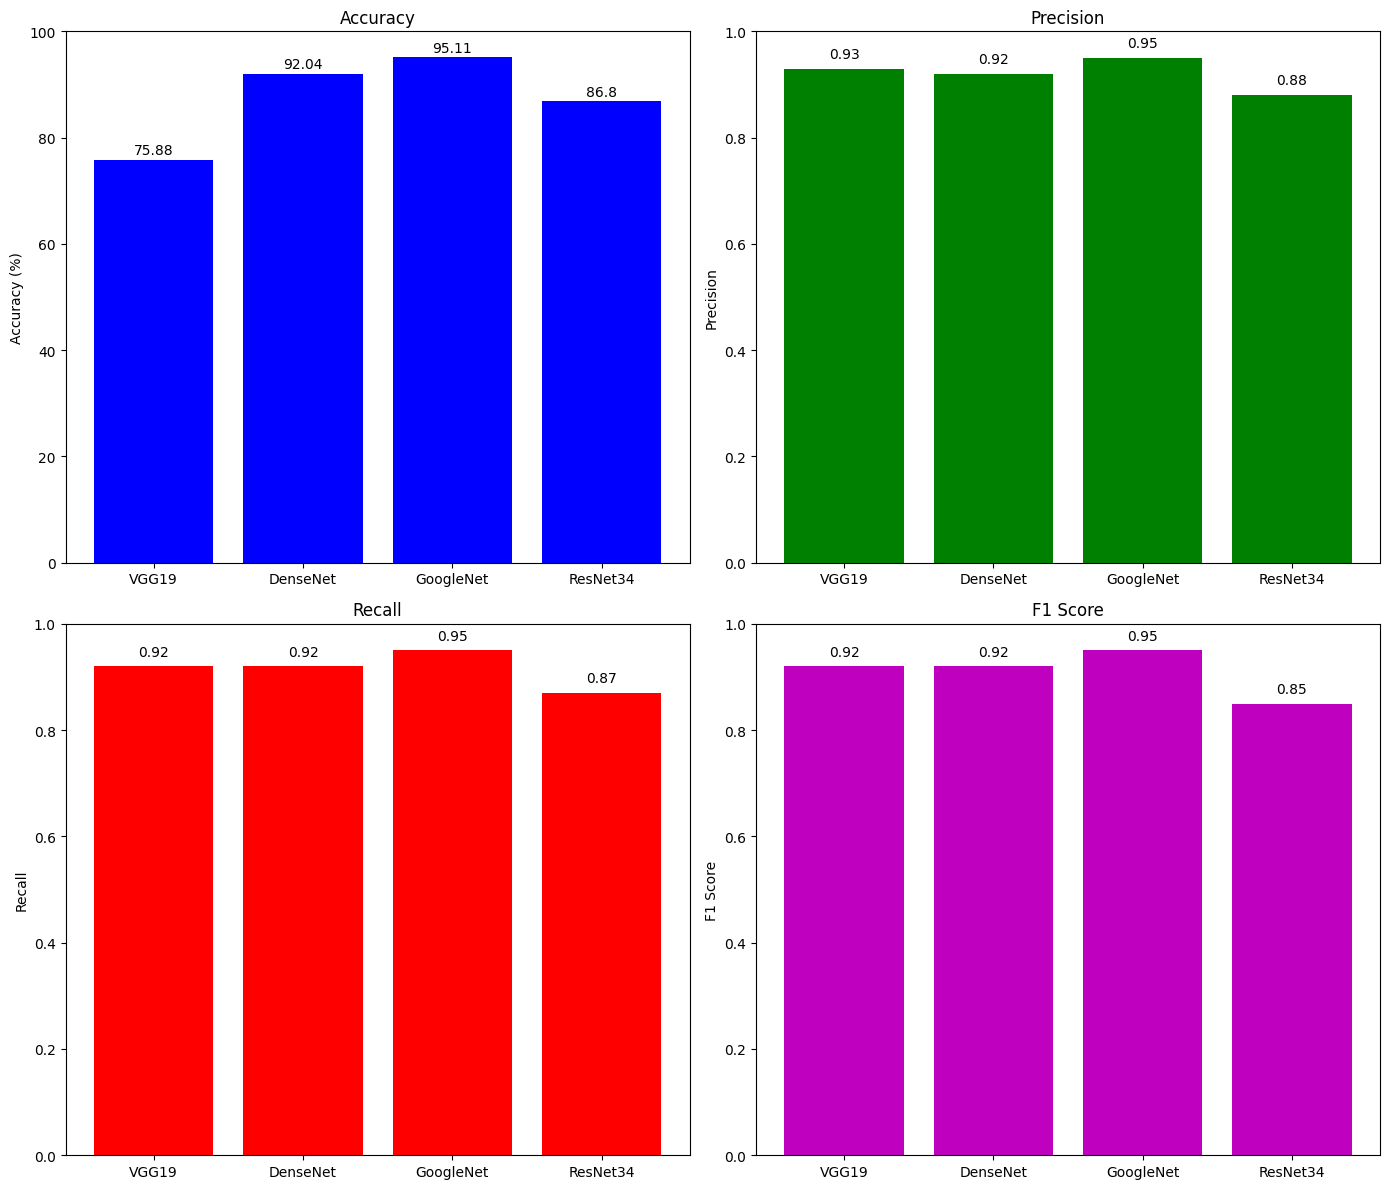

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Data for the models
models = ['VGG19', 'DenseNet', 'GoogleNet', 'ResNet34']
accuracy = [75.88, 92.04, 95.11, 86.80]
precision = [0.93, 0.92, 0.95, 0.88]
recall = [0.92, 0.92, 0.95, 0.87]
f1_score = [0.92, 0.92, 0.95, 0.85]

# Create a figure with subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 12))

# Accuracy plot
axs[0, 0].bar(models, accuracy, color='b')
axs[0, 0].set_title('Accuracy')
axs[0, 0].set_ylabel('Accuracy (%)')
axs[0, 0].set_ylim(0, 100)
for i, v in enumerate(accuracy):
    axs[0, 0].text(i, v + 1, str(v), ha='center')

# Precision plot
axs[0, 1].bar(models, precision, color='g')
axs[0, 1].set_title('Precision')
axs[0, 1].set_ylabel('Precision')
axs[0, 1].set_ylim(0, 1)
for i, v in enumerate(precision):
    axs[0, 1].text(i, v + 0.02, str(v), ha='center')

# Recall plot
axs[1, 0].bar(models, recall, color='r')
axs[1, 0].set_title('Recall')
axs[1, 0].set_ylabel('Recall')
axs[1, 0].set_ylim(0, 1)
for i, v in enumerate(recall):
    axs[1, 0].text(i, v + 0.02, str(v), ha='center')

# F1 Score plot
axs[1, 1].bar(models, f1_score, color='m')
axs[1, 1].set_title('F1 Score')
axs[1, 1].set_ylabel('F1 Score')
axs[1, 1].set_ylim(0, 1)
for i, v in enumerate(f1_score):
    axs[1, 1].text(i, v + 0.02, str(v), ha='center')

# Adjust layout
plt.tight_layout()
plt.show()


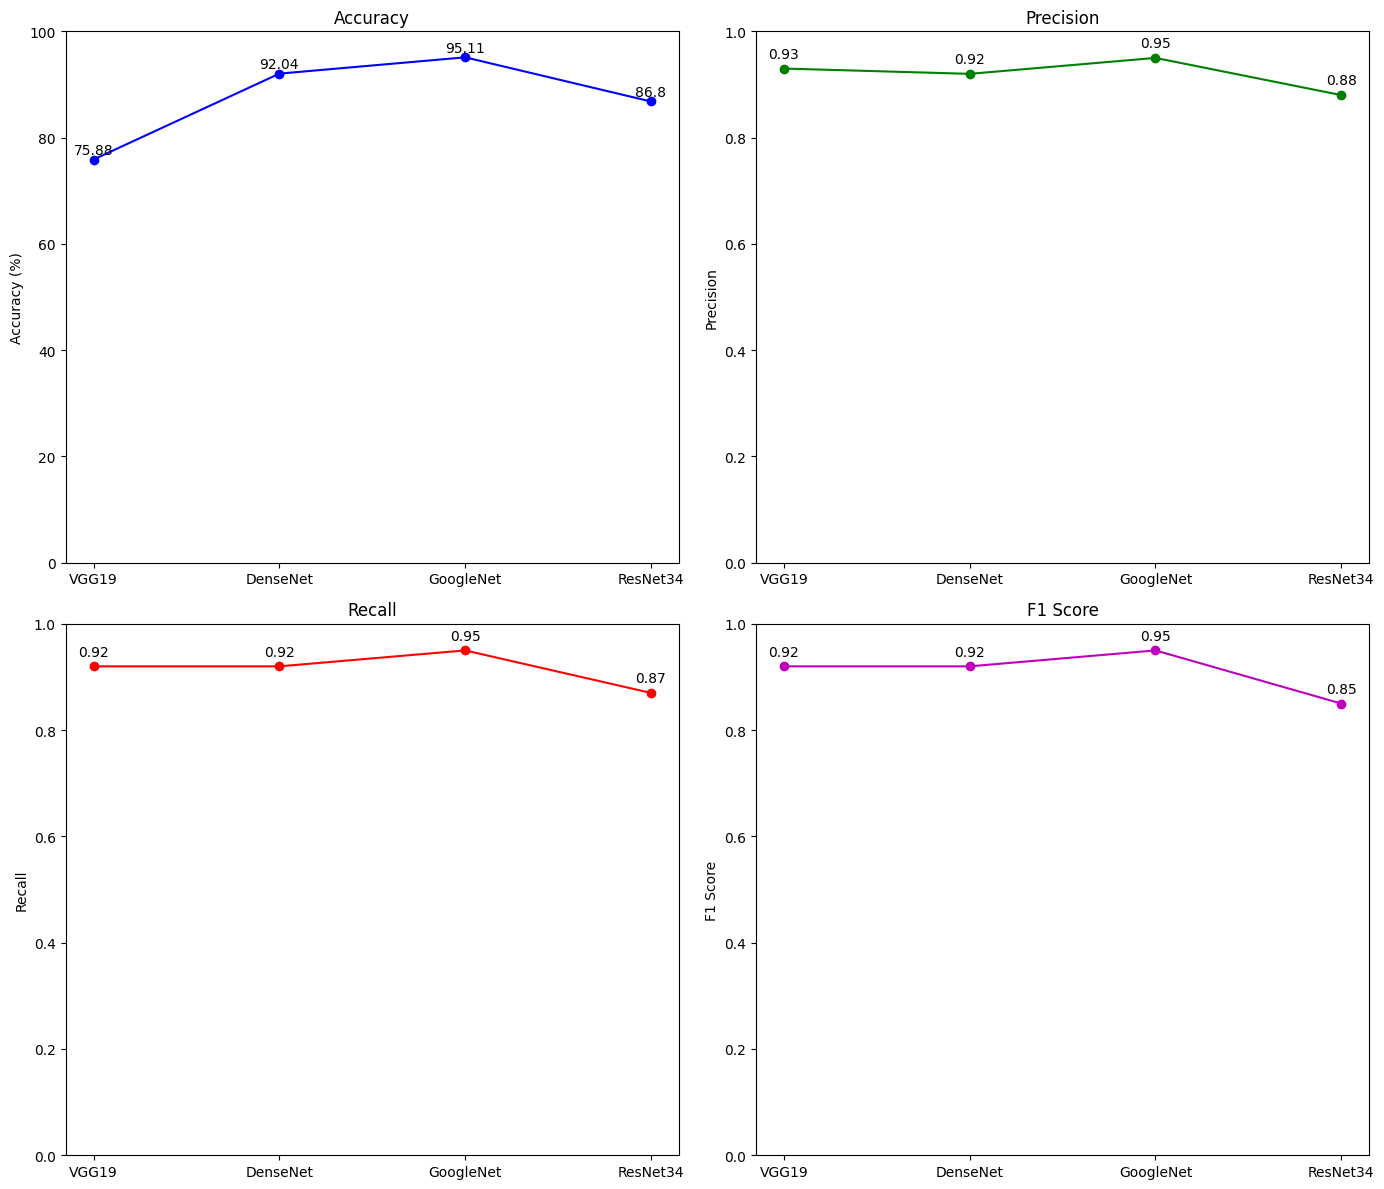

In [3]:
import matplotlib.pyplot as plt

# Data for the models
models = ['VGG19', 'DenseNet', 'GoogleNet', 'ResNet34']
accuracy = [75.88, 92.04, 95.11, 86.80]
precision = [0.93, 0.92, 0.95, 0.88]
recall = [0.92, 0.92, 0.95, 0.87]
f1_score = [0.92, 0.92, 0.95, 0.85]

# Create a figure with subplots for line graphs
fig, axs = plt.subplots(2, 2, figsize=(14, 12))

# Line plot for Accuracy
axs[0, 0].plot(models, accuracy, marker='o', linestyle='-', color='b')
axs[0, 0].set_title('Accuracy')
axs[0, 0].set_ylabel('Accuracy (%)')
axs[0, 0].set_ylim(0, 100)
for i, v in enumerate(accuracy):
    axs[0, 0].text(i, v + 1, str(v), ha='center')

# Line plot for Precision
axs[0, 1].plot(models, precision, marker='o', linestyle='-', color='g')
axs[0, 1].set_title('Precision')
axs[0, 1].set_ylabel('Precision')
axs[0, 1].set_ylim(0, 1)
for i, v in enumerate(precision):
    axs[0, 1].text(i, v + 0.02, str(v), ha='center')

# Line plot for Recall
axs[1, 0].plot(models, recall, marker='o', linestyle='-', color='r')
axs[1, 0].set_title('Recall')
axs[1, 0].set_ylabel('Recall')
axs[1, 0].set_ylim(0, 1)
for i, v in enumerate(recall):
    axs[1, 0].text(i, v + 0.02, str(v), ha='center')

# Line plot for F1 Score
axs[1, 1].plot(models, f1_score, marker='o', linestyle='-', color='m')
axs[1, 1].set_title('F1 Score')
axs[1, 1].set_ylabel('F1 Score')
axs[1, 1].set_ylim(0, 1)
for i, v in enumerate(f1_score):
    axs[1, 1].text(i, v + 0.02, str(v), ha='center')

# Adjust layout
plt.tight_layout()
plt.show()
